# SHAP Feature Importance Analysis

This notebook performs feature importance analysis using SHAP (SHapley Additive exPlanations) to understand which audio features contribute most to our Genre classification models.

SHAP provides:
- **Global feature importance**: Which features matter most overall
- **Local explanations**: Why individual predictions were made
- **Feature interactions**: How features work together
- **Per-class importance**: Which features matter for specific genres

In [1]:
# Automatically reload imported modules before executing code
%load_ext autoreload
%autoreload 2

In [2]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

In [3]:
from nbutils import setup_path
setup_path()

from models import load_model
from utils import get_clean_songs
from processing import ProcessingResult
from pyrekordbox import Rekordbox6Database

pl.Config.set_tbl_rows(30)

polars.config.Config

## 1. Load Model and Data

Load the trained models and prepare the test data.

In [4]:
# Load database
db = Rekordbox6Database()

# Find and load latest models
models_dir = Path("../models")
rf_model_file = sorted(models_dir.glob("random_forest_Genre_*_model.pkl"))[-1]
xgb_model_file = sorted(models_dir.glob("xgboost_Genre_*_model.pkl"))[-1]

print(f"Loading Random Forest: {rf_model_file.name}")
rf_data = load_model(str(rf_model_file))

print(f"\nLoading XGBoost: {xgb_model_file.name}")
xgb_data = load_model(str(xgb_model_file))

[10:07:04] pyrekordbox.db6.database:WARNING  - Rekordbox is running!


Loading Random Forest: random_forest_Genre_20251015_232027_model.pkl

MODEL LOADED SUCCESSFULLY
Model name: random_forest_Genre
Tag group: Genre
Number of labels: 22
Saved on: 2025-10-15T23:20:27.523168

Loaded components:
  Model: ✓
  Thresholds: ✓
  Scaler: ✓
  PCA: ✗

Stored metrics:
  macro_f1: 0.4909
  macro_precision: 0.4601
  macro_recall: 0.6430


Loading XGBoost: xgboost_Genre_20251015_232027_model.pkl

MODEL LOADED SUCCESSFULLY
Model name: xgboost_Genre
Tag group: Genre
Number of labels: 22
Saved on: 2025-10-15T23:20:27.538256

Loaded components:
  Model: ✓
  Thresholds: ✓
  Scaler: ✓
  PCA: ✗

Stored metrics:
  macro_f1: 0.5060
  macro_precision: 0.4732
  macro_recall: 0.6371



In [5]:
# Load features and prepare test data
features_df = pl.read_parquet("../data/song_features.parquet")

# Define feature columns (same exclusions as training)
exclude_cols = [
    "song_path", "harmonic_percussive_ratio", "percussive_strength",
    "tonnetz_mean_0", "tonnetz_mean_1", "tonnetz_mean_2", "tonnetz_mean_3", "tonnetz_mean_4", "tonnetz_mean_5",
    "tonnetz_std_0", "tonnetz_std_1", "tonnetz_std_2", "tonnetz_std_3", "tonnetz_std_4", "tonnetz_std_5"
]
feature_cols = [col for col in features_df.columns if col not in exclude_cols + ["song_id", "song_path"]]

# Filter and prepare features
features_df = features_df.filter(pl.col("energy_increase_ratio").is_not_null())
X = features_df.select(["song_id"] + feature_cols)

# Scale features using the saved scaler
X_scaled = rf_data['scaler'].transform(X.drop("song_id"))
X_scaled = pl.concat([X.select("song_id"), X_scaled], how="horizontal")

print(f"\nPrepared {X_scaled.shape[0]} songs with {len(feature_cols)} features")
print(f"Feature names: {feature_cols[:5]}... (showing first 5)")


Prepared 515 songs with 360 features
Feature names: ['mel_spec_mean_0', 'mel_spec_mean_1', 'mel_spec_mean_2', 'mel_spec_mean_3', 'mel_spec_mean_4']... (showing first 5)


## 2. Install and Import SHAP

SHAP provides model-agnostic explanations based on game theory.

In [6]:
# Install SHAP if not already installed
try:
    import shap
    print(f"SHAP version: {shap.__version__}")
except ImportError:
    print("Installing SHAP...")
    !pip install shap
    import shap
    print(f"SHAP version: {shap.__version__}")

SHAP version: 0.49.1


/Users/quintenrosseel/Development/personal/music_tagger/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. SHAP Analysis for Random Forest

Random Forest has native SHAP support via TreeExplainer, which is very fast.

In [7]:
# Sample data for SHAP analysis (use subset for faster computation)
# For full analysis, set sample_size = None
sample_size = 100  # Adjust based on computational resources

if sample_size and sample_size < len(X_scaled):
    print(f"Using random sample of {sample_size} songs for SHAP analysis")
    X_sample = X_scaled.sample(n=sample_size, seed=42)
else:
    print(f"Using all {len(X_scaled)} songs for SHAP analysis")
    X_sample = X_scaled

X_sample_np = X_sample.drop("song_id").to_numpy()
print(f"Sample shape: {X_sample_np.shape}")

Using random sample of 100 songs for SHAP analysis
Sample shape: (100, 360)


### 3.1 Create SHAP Explainer for Random Forest

For multi-output models, we need to explain each output (genre) separately.

In [8]:
# Random Forest is a MultiOutputClassifier, so we need to handle each estimator
rf_model = rf_data['model']
tags = rf_data['tags']

print(f"Analyzing {len(tags)} genre classifiers")
print(f"Genres: {tags}")

Analyzing 22 genre classifiers
Genres: ['Ambient', 'Bass', 'Beats', 'Breakbeat', 'Disco', 'Eurodance', 'Funk', 'Garage', 'Hip-Hop', 'House', 'Indie', 'Jazz', 'Motown', 'Old School', 'Pop', 'R&B', 'Rap', 'Rock', 'Soul', 'Techno', 'Trance', 'Tribal']


In [9]:
# Calculate SHAP values for each genre classifier
print("Computing SHAP values for each genre...")
print("This may take a few minutes depending on sample size...\n")

rf_shap_values = {}
rf_explainers = {}

for idx, tag in enumerate(tags):
    print(f"Processing {idx + 1}/{len(tags)}: {tag}")
    
    # Get the individual classifier for this tag
    estimator = rf_model.estimators_[idx]
    
    # Create TreeExplainer for this classifier
    explainer = shap.TreeExplainer(estimator)
    
    # Calculate SHAP values
    shap_values = explainer.shap_values(X_sample_np)
    
    # For binary classification, shap_values is a list [class_0, class_1]
    # We want class_1 (positive class)
    if isinstance(shap_values, list) and len(shap_values) == 2:
        shap_values = shap_values[1]
    elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
        # Alternative format: (n_sample/s, n_features, n_classes)
        shap_values = shap_values[:, :, 1]
    
    rf_shap_values[tag] = shap_values
    rf_explainers[tag] = explainer

print("\nSHAP computation complete!")
print(f"SHAP values shape for {tags[0]}: {rf_shap_values[tags[0]].shape}")

Computing SHAP values for each genre...
This may take a few minutes depending on sample size...

Processing 1/22: Ambient
Processing 2/22: Bass
Processing 3/22: Beats
Processing 4/22: Breakbeat
Processing 5/22: Disco
Processing 6/22: Eurodance
Processing 7/22: Funk
Processing 8/22: Garage
Processing 9/22: Hip-Hop
Processing 10/22: House
Processing 11/22: Indie
Processing 12/22: Jazz
Processing 13/22: Motown
Processing 14/22: Old School
Processing 15/22: Pop
Processing 16/22: R&B
Processing 17/22: Rap
Processing 18/22: Rock
Processing 19/22: Soul
Processing 20/22: Techno
Processing 21/22: Trance
Processing 22/22: Tribal

SHAP computation complete!
SHAP values shape for Ambient: (100, 360)


### 3.2 Global Feature Importance (Random Forest)

Aggregate SHAP values across all genres to see which features are most important overall.

In [10]:
# Calculate mean absolute SHAP values for each feature across all genres
mean_shap_values = np.zeros(len(feature_cols))

for tag, shap_vals in rf_shap_values.items():
    mean_shap_values += np.abs(shap_vals).mean(axis=0)

# Average across all genres
mean_shap_values /= len(tags)

# Create DataFrame for easy viewing
importance_df = pl.DataFrame({
    "feature": feature_cols,
    "importance": mean_shap_values
}).sort("importance", descending=True)

print("Top 20 Most Important Features (Random Forest):")
print(importance_df.head(20))

Top 20 Most Important Features (Random Forest):
shape: (20, 2)
┌──────────────────────────┬────────────┐
│ feature                  ┆ importance │
│ ---                      ┆ ---        │
│ str                      ┆ f64        │
╞══════════════════════════╪════════════╡
│ beat_count               ┆ 0.030822   │
│ tempo_0                  ┆ 0.023519   │
│ onset_rate               ┆ 0.018193   │
│ mfcc_std_5               ┆ 0.008055   │
│ energy_middle            ┆ 0.007795   │
│ mfcc_mean_15             ┆ 0.007618   │
│ mel_spec_std_0           ┆ 0.007313   │
│ mfcc_mean_6              ┆ 0.0073     │
│ mfcc_mean_19             ┆ 0.006816   │
│ mfcc_std_8               ┆ 0.006558   │
│ mfcc_mean_13             ┆ 0.00625    │
│ mfcc_std_10              ┆ 0.005709   │
│ beat_regularity          ┆ 0.005649   │
│ mel_spec_mean_4          ┆ 0.004861   │
│ spectral_contrast_mean_0 ┆ 0.004582   │
│ mel_spec_mean_8          ┆ 0.004557   │
│ mel_spec_mean_9          ┆ 0.004533   │
│ mfcc_std_3 

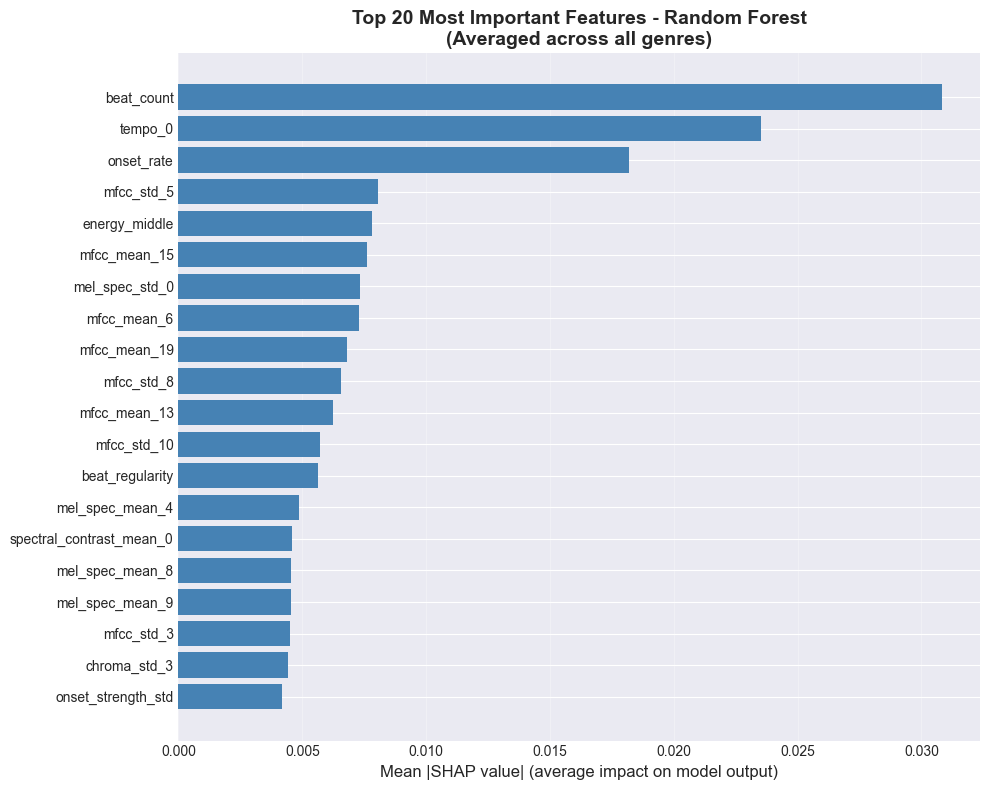

In [11]:
# Plot global feature importance
fig, ax = plt.subplots(figsize=(10, 8))

top_n = 20
top_features = importance_df.head(top_n)

ax.barh(
    range(top_n),
    top_features["importance"].to_list()[::-1],
    color='steelblue'
)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features["feature"].to_list()[::-1])
ax.set_xlabel('Mean |SHAP value| (average impact on model output)', fontsize=12)
ax.set_title(f'Top {top_n} Most Important Features - Random Forest\n(Averaged across all genres)', 
             fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### 3.3 Per-Genre Feature Importance (Random Forest)

See which features are most important for specific genres.

In [12]:
# Select a genre to analyze in detail
genre_to_analyze = tags[0]  # Change index to analyze different genres
print(f"Analyzing feature importance for: {genre_to_analyze}")
print(f"\nAvailable genres: {tags}")

Analyzing feature importance for: Ambient

Available genres: ['Ambient', 'Bass', 'Beats', 'Breakbeat', 'Disco', 'Eurodance', 'Funk', 'Garage', 'Hip-Hop', 'House', 'Indie', 'Jazz', 'Motown', 'Old School', 'Pop', 'R&B', 'Rap', 'Rock', 'Soul', 'Techno', 'Trance', 'Tribal']


In [13]:
# Calculate feature importance for selected genre
genre_shap = rf_shap_values[genre_to_analyze]
genre_importance = np.abs(genre_shap).mean(axis=0)

genre_importance_df = pl.DataFrame({
    "feature": feature_cols,
    "importance": genre_importance
}).sort("importance", descending=True)

print(f"\nTop 15 Features for {genre_to_analyze}:")
print(genre_importance_df.head(15))


Top 15 Features for Ambient:
shape: (15, 2)
┌──────────────────┬────────────┐
│ feature          ┆ importance │
│ ---              ┆ ---        │
│ str              ┆ f64        │
╞══════════════════╪════════════╡
│ mfcc_mean_2      ┆ 0.028698   │
│ mel_spec_mean_72 ┆ 0.022904   │
│ mel_spec_mean_55 ┆ 0.016091   │
│ mel_spec_std_0   ┆ 0.012892   │
│ chroma_std_1     ┆ 0.011995   │
│ mel_spec_mean_73 ┆ 0.01158    │
│ zcr_mean         ┆ 0.008581   │
│ mel_spec_mean_51 ┆ 0.008376   │
│ mel_spec_mean_63 ┆ 0.008283   │
│ mel_spec_mean_71 ┆ 0.008136   │
│ mfcc_std_7       ┆ 0.007466   │
│ chroma_std_9     ┆ 0.007298   │
│ mel_spec_mean_48 ┆ 0.00689    │
│ mfcc_mean_10     ┆ 0.006886   │
│ beat_regularity  ┆ 0.006807   │
└──────────────────┴────────────┘


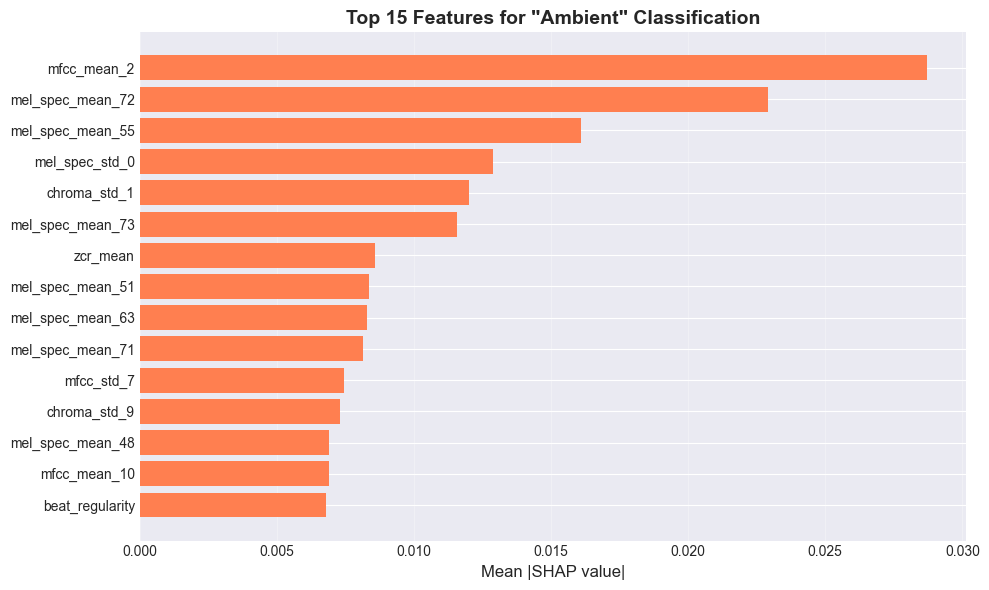

In [14]:
# Plot per-genre feature importance
fig, ax = plt.subplots(figsize=(10, 6))

top_n = 15
top_features = genre_importance_df.head(top_n)

ax.barh(
    range(top_n),
    top_features["importance"].to_list()[::-1],
    color='coral'
)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features["feature"].to_list()[::-1])
ax.set_xlabel('Mean |SHAP value|', fontsize=12)
ax.set_title(f'Top {top_n} Features for "{genre_to_analyze}" Classification', 
             fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### 3.4 SHAP Summary Plot (Random Forest)

This shows both feature importance and the distribution of impacts.

SHAP Summary Plot for: Ambient


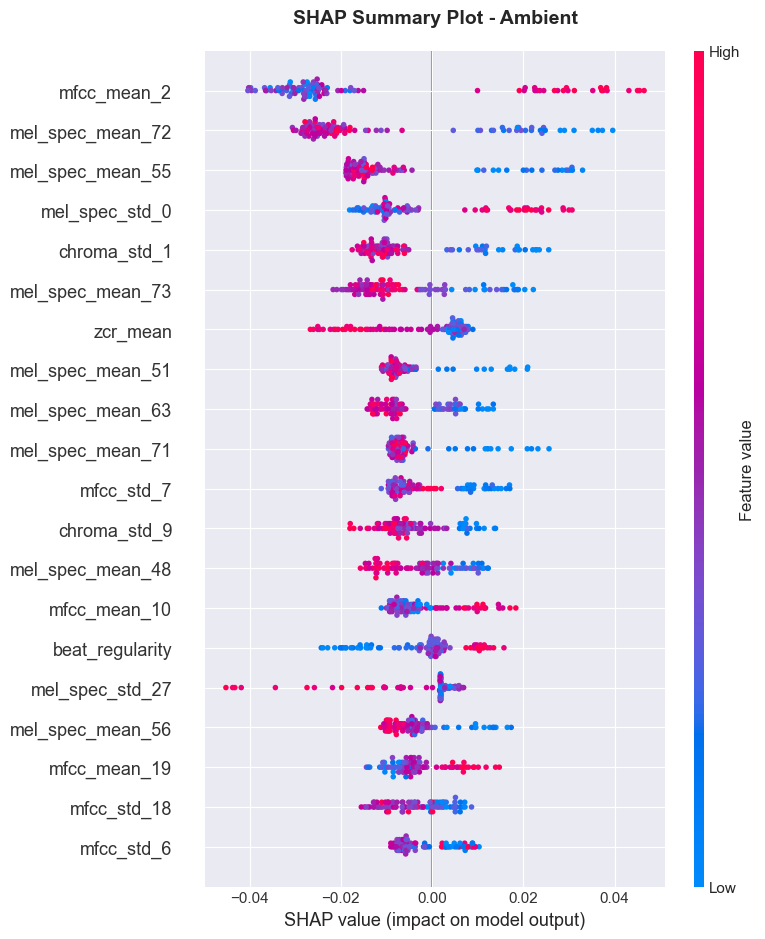

In [15]:
# Summary plot for selected genre
print(f"SHAP Summary Plot for: {genre_to_analyze}")

plt.figure(figsize=(10, 8))
shap.summary_plot(
    rf_shap_values[genre_to_analyze],
    X_sample_np,
    feature_names=feature_cols,
    max_display=20,
    show=False
)
plt.title(f'SHAP Summary Plot - {genre_to_analyze}', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

### 3.5 SHAP Dependence Plots (Random Forest)

Visualize how a single feature impacts predictions.

SHAP Dependence Plot for most important feature: mfcc_mean_2


<Figure size 1000x600 with 0 Axes>

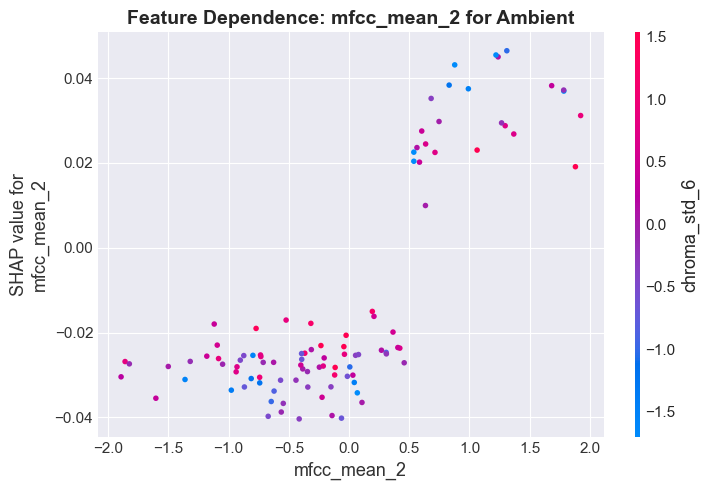

In [16]:
# Select top feature for dependence plot
top_feature = genre_importance_df["feature"][0]
feature_idx = feature_cols.index(top_feature)

print(f"SHAP Dependence Plot for most important feature: {top_feature}")

plt.figure(figsize=(10, 6))
shap.dependence_plot(
    feature_idx,
    rf_shap_values[genre_to_analyze],
    X_sample_np,
    feature_names=feature_cols,
    show=False
)
plt.title(f'Feature Dependence: {top_feature} for {genre_to_analyze}', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.6 Compare Feature Importance Across Multiple Genres

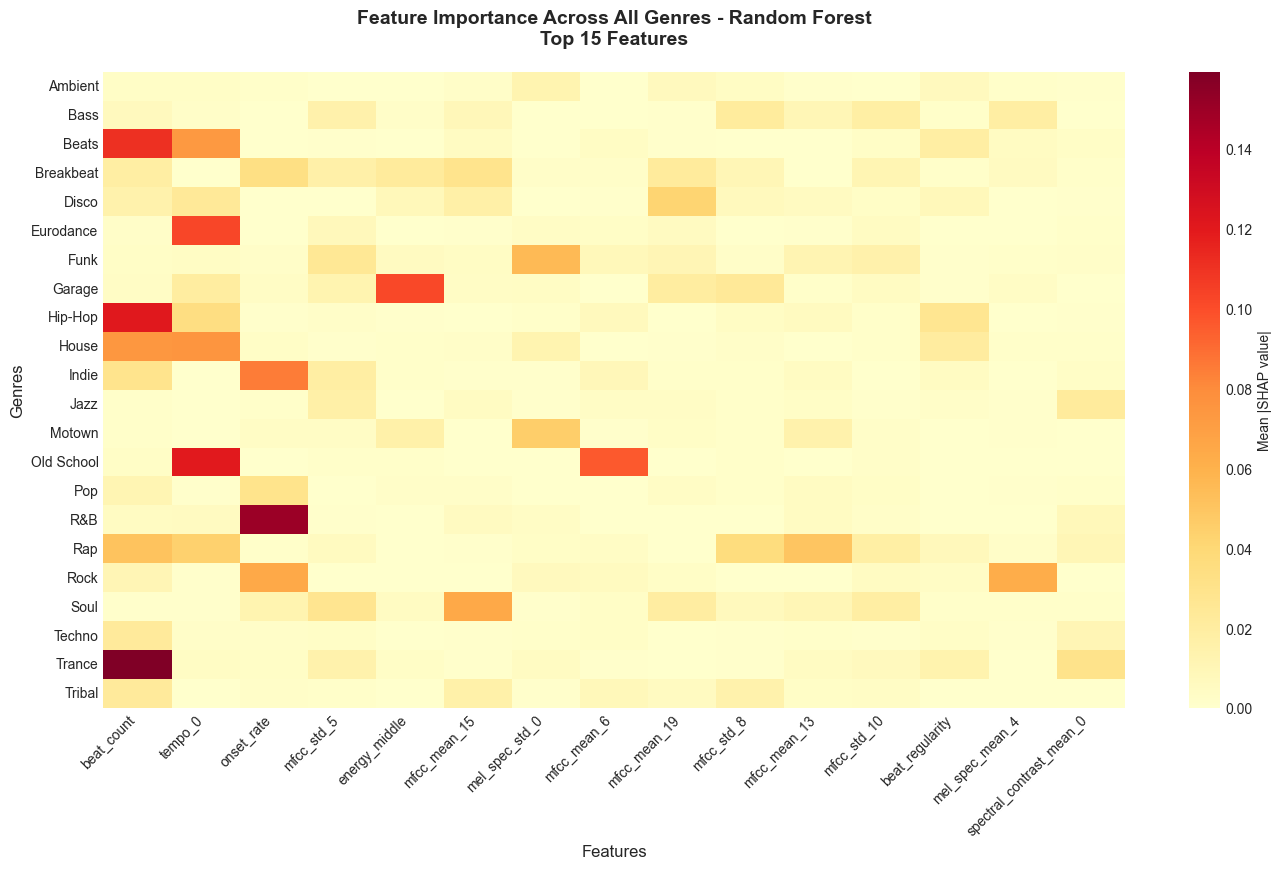

In [17]:
# Create heatmap of feature importance across genres
# Select top N features overall
top_n_features = 15
top_feature_names = importance_df["feature"].head(top_n_features).to_list()

# Build matrix: genres x features
importance_matrix = np.zeros((len(tags), top_n_features))

for genre_idx, tag in enumerate(tags):
    genre_shap = rf_shap_values[tag]
    genre_importance = np.abs(genre_shap).mean(axis=0)
    
    for feat_idx, feat_name in enumerate(top_feature_names):
        original_feat_idx = feature_cols.index(feat_name)
        importance_matrix[genre_idx, feat_idx] = genre_importance[original_feat_idx]

# Plot heatmap
fig, ax = plt.subplots(figsize=(14, max(8, len(tags) * 0.4)))

sns.heatmap(
    importance_matrix,
    xticklabels=top_feature_names,
    yticklabels=tags,
    cmap='YlOrRd',
    annot=False,
    fmt=".3f",
    cbar_kws={'label': 'Mean |SHAP value|'},
    ax=ax
)

ax.set_xlabel('Features', fontsize=12)
ax.set_ylabel('Genres', fontsize=12)
ax.set_title(f'Feature Importance Across All Genres - Random Forest\nTop {top_n_features} Features', 
             fontsize=14, fontweight='bold', pad=20)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. SHAP Analysis for XGBoost

Repeat the analysis for XGBoost model.

In [18]:
# Calculate SHAP values for XGBoost
print("Computing SHAP values for XGBoost model...")
print("This may take a few minutes...\n")

xgb_model = xgb_data['model']
xgb_shap_values = {}
xgb_explainers = {}

for idx, tag in enumerate(tags):
    print(f"Processing {idx + 1}/{len(tags)}: {tag}")
    
    # Get the individual classifier for this tag
    estimator = xgb_model.estimators_[idx]
    
    # Create TreeExplainer for XGBoost
    explainer = shap.TreeExplainer(estimator)
    
    # Calculate SHAP values
    shap_values = explainer.shap_values(X_sample_np)
    
    # XGBoost typically returns a single array for binary classification (positive class)
    # But handle both cases just in case
    if isinstance(shap_values, list) and len(shap_values) == 2:
        shap_values = shap_values[1]
    elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
        shap_values = shap_values[:, :, 1]
    
    xgb_shap_values[tag] = shap_values
    xgb_explainers[tag] = explainer

print("\nSHAP computation complete!")
print(f"SHAP values shape for {tags[0]}: {xgb_shap_values[tags[0]].shape}")

Computing SHAP values for XGBoost model...
This may take a few minutes...

Processing 1/22: Ambient
Processing 2/22: Bass
Processing 3/22: Beats
Processing 4/22: Breakbeat
Processing 5/22: Disco
Processing 6/22: Eurodance
Processing 7/22: Funk
Processing 8/22: Garage
Processing 9/22: Hip-Hop
Processing 10/22: House
Processing 11/22: Indie
Processing 12/22: Jazz
Processing 13/22: Motown
Processing 14/22: Old School
Processing 15/22: Pop
Processing 16/22: R&B
Processing 17/22: Rap
Processing 18/22: Rock
Processing 19/22: Soul
Processing 20/22: Techno
Processing 21/22: Trance
Processing 22/22: Tribal

SHAP computation complete!
SHAP values shape for Ambient: (100, 360)


### 4.1 Global Feature Importance (XGBoost)

In [19]:
# Calculate mean absolute SHAP values for XGBoost
xgb_mean_shap = np.zeros(len(feature_cols))

for tag, shap_vals in xgb_shap_values.items():
    xgb_mean_shap += np.abs(shap_vals).mean(axis=0)

xgb_mean_shap /= len(tags)

xgb_importance_df = pl.DataFrame({
    "feature": feature_cols,
    "importance": xgb_mean_shap
}).sort("importance", descending=True)

print("Top 20 Most Important Features (XGBoost):")
print(xgb_importance_df.head(20))

Top 20 Most Important Features (XGBoost):
shape: (20, 2)
┌──────────────────────────┬────────────┐
│ feature                  ┆ importance │
│ ---                      ┆ ---        │
│ str                      ┆ f64        │
╞══════════════════════════╪════════════╡
│ tempo_0                  ┆ 0.332101   │
│ beat_count               ┆ 0.305412   │
│ onset_rate               ┆ 0.239646   │
│ mfcc_std_5               ┆ 0.128264   │
│ mfcc_mean_6              ┆ 0.110153   │
│ energy_middle            ┆ 0.098079   │
│ mel_spec_std_0           ┆ 0.09783    │
│ spectral_contrast_std_1  ┆ 0.087317   │
│ mfcc_mean_19             ┆ 0.083596   │
│ spectral_contrast_mean_0 ┆ 0.077042   │
│ mfcc_mean_10             ┆ 0.07577    │
│ chroma_std_3             ┆ 0.075649   │
│ beat_regularity          ┆ 0.074705   │
│ spectral_contrast_mean_5 ┆ 0.074372   │
│ mfcc_std_2               ┆ 0.0712     │
│ mfcc_mean_13             ┆ 0.063008   │
│ rms_delta_std            ┆ 0.061042   │
│ chroma_mean_11   

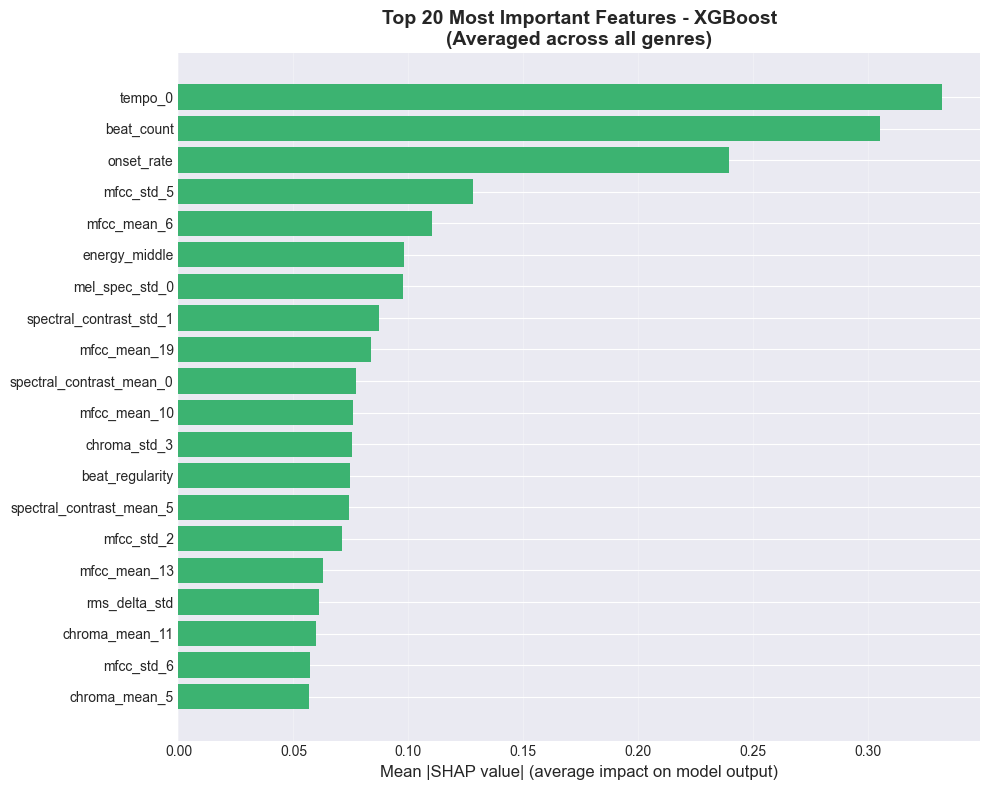

In [20]:
# Plot XGBoost global feature importance
fig, ax = plt.subplots(figsize=(10, 8))

top_n = 20
top_features = xgb_importance_df.head(top_n)

ax.barh(
    range(top_n),
    top_features["importance"].to_list()[::-1],
    color='mediumseagreen'
)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features["feature"].to_list()[::-1])
ax.set_xlabel('Mean |SHAP value| (average impact on model output)', fontsize=12)
ax.set_title(f'Top {top_n} Most Important Features - XGBoost\n(Averaged across all genres)', 
             fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### 4.2 SHAP Summary Plot (XGBoost)

SHAP Summary Plot for XGBoost: Ambient


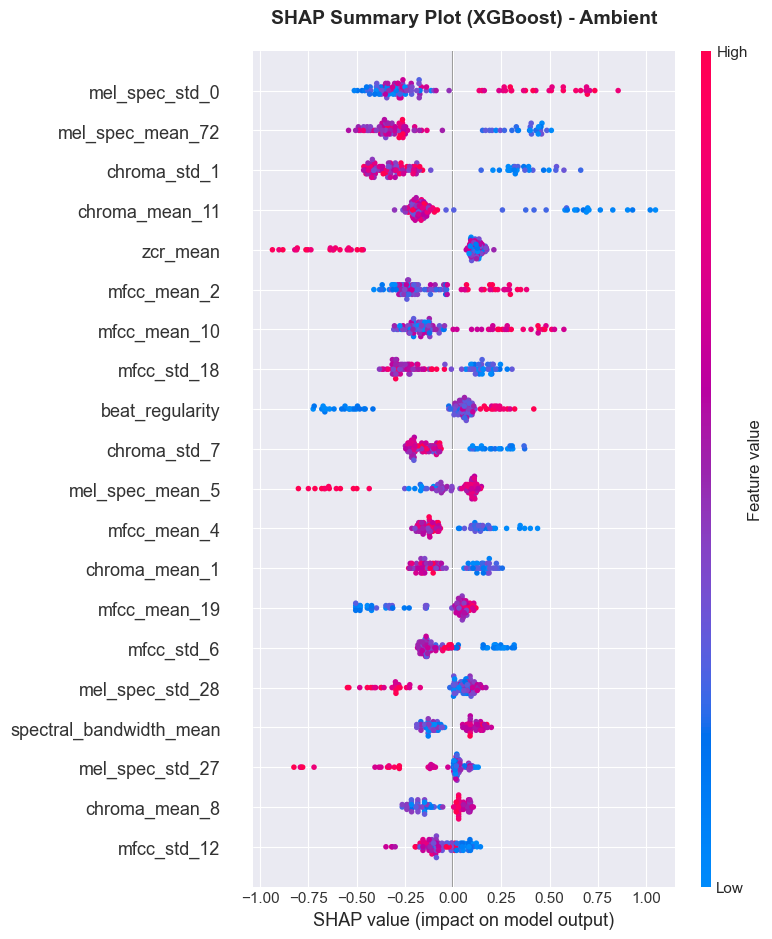

In [21]:
# Summary plot for XGBoost (same genre as Random Forest for comparison)
print(f"SHAP Summary Plot for XGBoost: {genre_to_analyze}")

plt.figure(figsize=(10, 8))
shap.summary_plot(
    xgb_shap_values[genre_to_analyze],
    X_sample_np,
    feature_names=feature_cols,
    max_display=20,
    show=False
)
plt.title(f'SHAP Summary Plot (XGBoost) - {genre_to_analyze}', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## 5. Compare Random Forest vs XGBoost Feature Importance

In [22]:
# Compare top features between models
comparison_df = importance_df.select([
    pl.col("feature"),
    pl.col("importance").alias("rf_importance")
]).join(
    xgb_importance_df.select([
        pl.col("feature"),
        pl.col("importance").alias("xgb_importance")
    ]),
    on="feature"
).with_columns(
    ((pl.col("rf_importance") + pl.col("xgb_importance")) / 2).alias("avg_importance")
).sort("avg_importance", descending=True)

print("Top 20 Features - Model Comparison:")
print(comparison_df.head(20))

Top 20 Features - Model Comparison:
shape: (20, 4)
┌──────────────────────────┬───────────────┬────────────────┬────────────────┐
│ feature                  ┆ rf_importance ┆ xgb_importance ┆ avg_importance │
│ ---                      ┆ ---           ┆ ---            ┆ ---            │
│ str                      ┆ f64           ┆ f64            ┆ f64            │
╞══════════════════════════╪═══════════════╪════════════════╪════════════════╡
│ tempo_0                  ┆ 0.023519      ┆ 0.332101       ┆ 0.17781        │
│ beat_count               ┆ 0.030822      ┆ 0.305412       ┆ 0.168117       │
│ onset_rate               ┆ 0.018193      ┆ 0.239646       ┆ 0.128919       │
│ mfcc_std_5               ┆ 0.008055      ┆ 0.128264       ┆ 0.068159       │
│ mfcc_mean_6              ┆ 0.0073        ┆ 0.110153       ┆ 0.058727       │
│ energy_middle            ┆ 0.007795      ┆ 0.098079       ┆ 0.052937       │
│ mel_spec_std_0           ┆ 0.007313      ┆ 0.09783        ┆ 0.052571       │
│

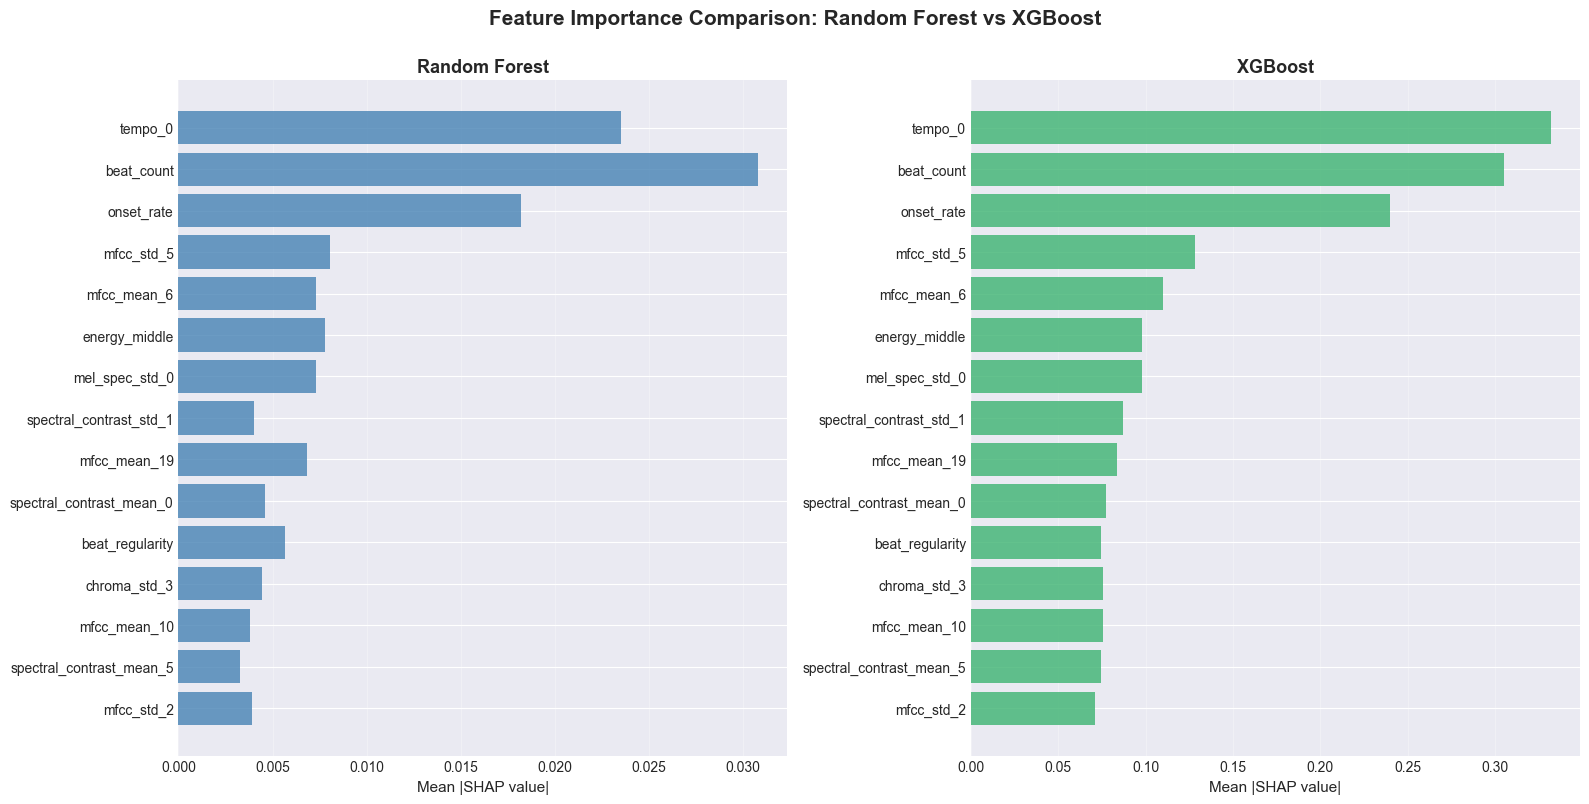

In [23]:
# Side-by-side comparison plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

top_n = 15
top_features_both = comparison_df.head(top_n)

# Random Forest
ax1.barh(
    range(top_n),
    top_features_both["rf_importance"].to_list()[::-1],
    color='steelblue',
    alpha=0.8
)
ax1.set_yticks(range(top_n))
ax1.set_yticklabels(top_features_both["feature"].to_list()[::-1])
ax1.set_xlabel('Mean |SHAP value|', fontsize=11)
ax1.set_title('Random Forest', fontsize=13, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# XGBoost
ax2.barh(
    range(top_n),
    top_features_both["xgb_importance"].to_list()[::-1],
    color='mediumseagreen',
    alpha=0.8
)
ax2.set_yticks(range(top_n))
ax2.set_yticklabels(top_features_both["feature"].to_list()[::-1])
ax2.set_xlabel('Mean |SHAP value|', fontsize=11)
ax2.set_title('XGBoost', fontsize=13, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

fig.suptitle('Feature Importance Comparison: Random Forest vs XGBoost', 
             fontsize=15, fontweight='bold', y=1.00)

plt.tight_layout()
plt.show()

## 6. Individual Prediction Explanations

Explain why the model made specific predictions for individual songs.

In [24]:
# Select a random song to explain
song_idx = 0  # Change this to analyze different songs
song_id = X_sample.select("song_id")[song_idx, 0]

# Get song metadata
songs_df = get_clean_songs(db, rename=True)
song_info = songs_df.filter(pl.col("song_id") == song_id)

print("Explaining prediction for:")
print(f"  Artist: {song_info['artist_name'][0]}")
print(f"  Title: {song_info['song_title'][0]}")
print(f"  Song ID: {song_id}")

Explaining prediction for:
  Artist: AndrewWav
  Title: Midnight Bump
  Song ID: 228193051


In [25]:
# Get predictions for this song
song_features = X_sample_np[song_idx:song_idx+1]

print("\nPredictions for this song:")
print("\nRandom Forest:")
for idx, tag in enumerate(tags):
    estimator = rf_model.estimators_[idx]
    prob = estimator.predict_proba(song_features)[0, 1]
    threshold = rf_data['thresholds'][idx] if rf_data['thresholds'] is not None else 0.5
    predicted = prob >= threshold
    print(f"  {tag:20s}: {prob:.3f} (threshold: {threshold:.3f}) - {'✓ PREDICTED' if predicted else '✗'}")


Predictions for this song:

Random Forest:
  Ambient             : 0.266 (threshold: 0.253) - ✓ PREDICTED
  Bass                : 0.324 (threshold: 0.512) - ✗
  Beats               : 0.295 (threshold: 0.330) - ✗
  Breakbeat           : 0.174 (threshold: 0.389) - ✗
  Disco               : 0.186 (threshold: 0.545) - ✗
  Eurodance           : 0.303 (threshold: 0.206) - ✓ PREDICTED
  Funk                : 0.151 (threshold: 0.310) - ✗
  Garage              : 0.165 (threshold: 0.614) - ✗
  Hip-Hop             : 0.125 (threshold: 0.326) - ✗
  House               : 0.322 (threshold: 0.381) - ✗
  Indie               : 0.151 (threshold: 0.211) - ✗
  Jazz                : 0.223 (threshold: 0.275) - ✗
  Motown              : 0.086 (threshold: 0.000) - ✓ PREDICTED
  Old School          : 0.010 (threshold: 0.361) - ✗
  Pop                 : 0.333 (threshold: 0.341) - ✗
  R&B                 : 0.048 (threshold: 0.517) - ✗
  Rap                 : 0.039 (threshold: 0.379) - ✗
  Rock                : 0


Explaining why the model predicted (or didn't predict): Ambient


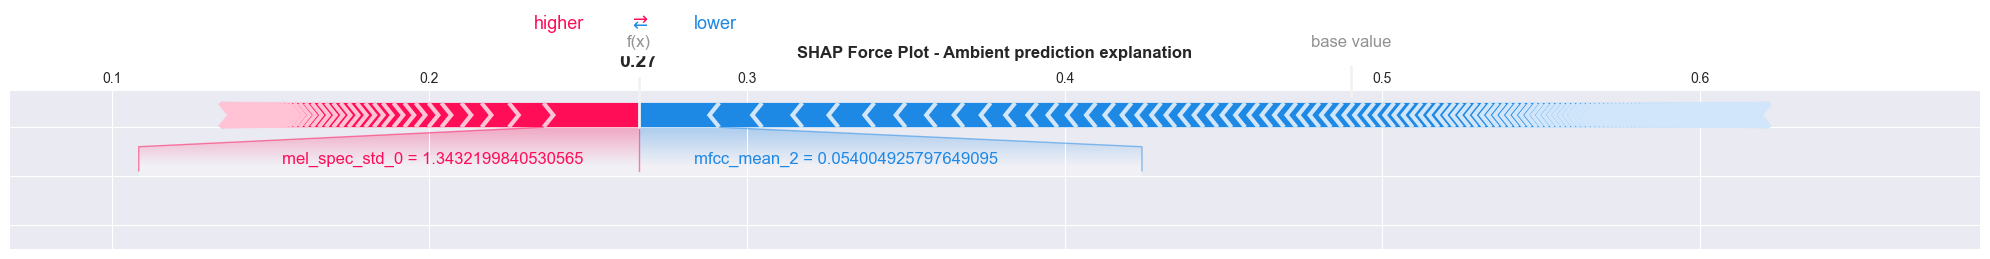

In [26]:
# SHAP force plot for a specific genre prediction
# Select a genre that was predicted
genre_to_explain = genre_to_analyze

print(f"\nExplaining why the model predicted (or didn't predict): {genre_to_explain}")

# Get SHAP values for this single prediction
explainer = rf_explainers[genre_to_explain]
shap_value = rf_shap_values[genre_to_explain][song_idx]

# Get the expected value (baseline) - handle both scalar and array formats
expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)):
    expected_value = expected_value[1]  # Use positive class baseline

# Force plot
shap.force_plot(
    expected_value,
    shap_value,
    song_features[0],
    feature_names=feature_cols,
    matplotlib=True,
    show=False
)
plt.title(f'SHAP Force Plot - {genre_to_explain} prediction explanation', 
          fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

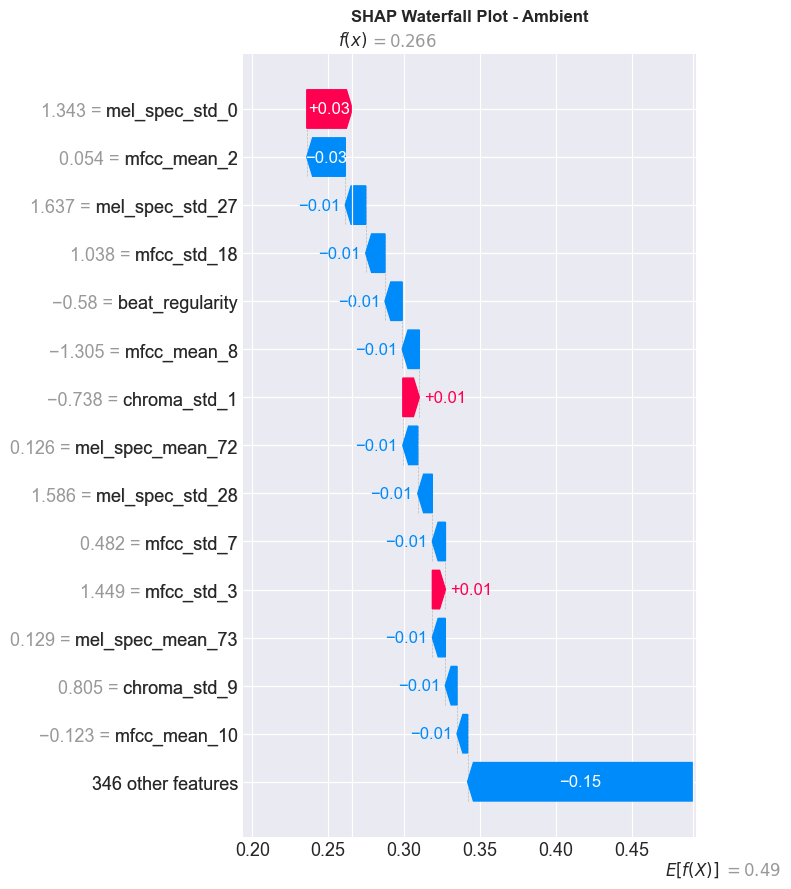

In [27]:
# Waterfall plot (alternative visualization)
# Get the expected value (baseline) - handle both scalar and array formats
expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)):
    expected_value = expected_value[1]  # Use positive class baseline

shap.waterfall_plot(
    shap.Explanation(
        values=shap_value,
        base_values=expected_value,
        data=song_features[0],
        feature_names=feature_cols
    ),
    max_display=15,
    show=False
)
plt.title(f'SHAP Waterfall Plot - {genre_to_explain}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Save Results

Save the feature importance analysis results for future reference.

In [28]:
# Save feature importance rankings
output_dir = Path("../reports/shap_analysis")
output_dir.mkdir(parents=True, exist_ok=True)

# Save comparison table
comparison_df.write_csv(output_dir / "feature_importance_comparison.csv")
print(f"Saved feature importance comparison to {output_dir / 'feature_importance_comparison.csv'}")

# Save per-genre importance for Random Forest
for tag in tags:
    genre_shap = rf_shap_values[tag]
    genre_importance = np.abs(genre_shap).mean(axis=0)
    
    genre_df = pl.DataFrame({
        "feature": feature_cols,
        "importance": genre_importance
    }).sort("importance", descending=True)
    
    safe_tag = tag.replace("/", "_").replace(" ", "_")
    genre_df.write_csv(output_dir / f"rf_{safe_tag}_importance.csv")

print(f"\nSaved per-genre importance files to {output_dir}/")

Saved feature importance comparison to ../reports/shap_analysis/feature_importance_comparison.csv

Saved per-genre importance files to ../reports/shap_analysis/


## Summary

This notebook performed comprehensive SHAP analysis to understand:

1. **Global Feature Importance**: Which audio features matter most across all genres
2. **Per-Genre Importance**: Which features are specific to certain genres
3. **Model Comparison**: How Random Forest and XGBoost use features differently
4. **Individual Predictions**: Why specific songs receive certain genre predictions

### Key Insights:
- SHAP values show not just feature importance, but also direction of impact
- Different genres rely on different audio features
- Feature importance can vary significantly between models
- Individual predictions can be explained and validated

### Next Steps:
- Use insights to engineer better features
- Remove redundant or low-importance features
- Fine-tune models based on feature interactions
- Validate findings with domain knowledge